# Avaliação de Modelos

Quais melhores modelos para testar as metricas
- Metricas a serem validadas:
    - F1 Score
    - ROC-AUC
- Modelos a serem testados:
    - Regressão
    - Decision Tree
    - randomforest
    - XGBoost

In [31]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,recall_score, precision_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay
from src.data.load_data import import_dataset
from src.config import features, features_cat, features_num, target
from src.preprocess import churn_mapped, create_preprocessor, train_test, total_charges


In [2]:
df = import_dataset(r"..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = total_charges(df)

In [3]:

X = df[features]
y = churn_mapped(df, target)


X_train, X_test, y_train, y_test = train_test(X,y)


In [4]:
preprocessor = create_preprocessor(features_num, features_cat)

# Regressão Logistica

In [42]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced',random_state=42, max_iter=1000))
])
pipeline_lr.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
y_pred = pipeline_lr.predict(X_test)
y_proba = pipeline_lr.predict_proba(X_test)[:,1]

In [44]:
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7374024130589071
Recall:  0.7834224598930482
Precision:  0.5034364261168385
F1-Score:  0.6129707112970711
ROC-AUC:  0.8414063912785139


In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



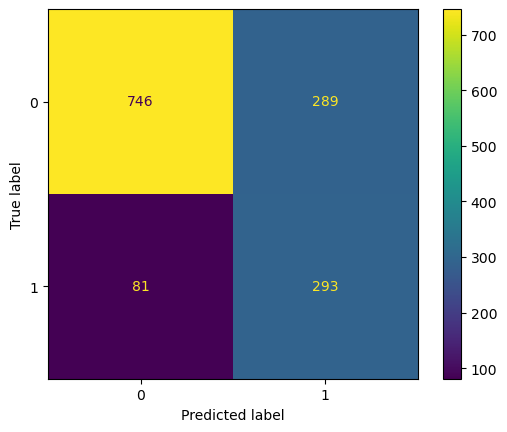

In [46]:
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))

# Arvore de Decisão

In [10]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [47]:
preprocessor_tree = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
            ],
        remainder='passthrough'
)
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(max_depth= 5, min_samples_split= 10, min_samples_leaf= 5, class_weight='balanced',random_state=42))
])
pipeline_dt.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
y_pred = pipeline_dt.predict(X_test)
y_proba = pipeline_dt.predict_proba(X_test)[:,1]

In [49]:
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7551454932576295
Recall:  0.7593582887700535
Precision:  0.5269016697588126
F1-Score:  0.6221248630887185
ROC-AUC:  0.8322793148880105


# Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier 

In [50]:
preprocessor_rf = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
            ],
        remainder='passthrough'
)
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(max_depth= 5, min_samples_split= 10, min_samples_leaf= 5, class_weight='balanced',random_state=42))
])
pipeline_rf.fit(X_train, y_train)


pipeline_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
y_pred = pipeline_rf.predict(X_test)
y_proba = pipeline_rf.predict_proba(X_test)[:,1]

In [52]:
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7374024130589071
Recall:  0.7887700534759359
Precision:  0.5034129692832765
F1-Score:  0.6145833333333334
ROC-AUC:  0.8390296830194528


# XGBoost

In [25]:
from xgboost import XGBClassifier

In [26]:
ratio = (y_train ==0).sum()/(y_train==1).sum()
ratio

np.float64(2.768561872909699)

In [27]:
preprocessor = create_preprocessor(features_num, features_cat)
ratio = (y_train ==0).sum()/(y_train==1).sum()
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(    max_depth=4,
    learning_rate=0.05,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3))
])

In [28]:
pipeline_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
y_pred = pipeline_xgb.predict(X_test)
y_proba = pipeline_xgb.predict_proba(X_test)[:,1]

In [30]:
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ', precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

print(classification_report(y_test, y_pred))

Accuracy:  0.7494677075940384
Recall:  0.7700534759358288
Precision:  0.518918918918919
F1-Score:  0.620021528525296
ROC-AUC:  0.8359967966106074
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



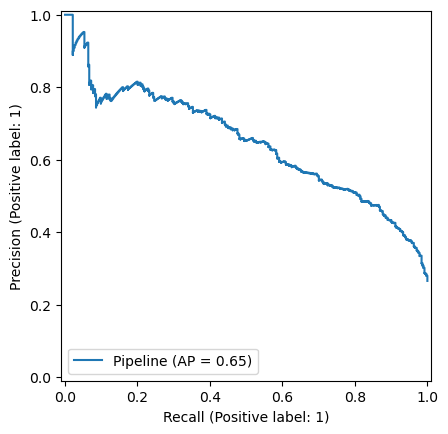

In [32]:
PrecisionRecallDisplay.from_estimator(pipeline_xgb, X_test, y_test)
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

y_proba = pipeline_xgb.predict_proba(X_test)[:, 1]

ap=average_precision_score(y_test, y_proba)
print(ap)

0.6479384606844372


# Testes com alteração no Threshold

In [60]:

def threshold(model, X_test,y_test):
    y_proba = model.predict_proba(X_test)[:, 1]

    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        
        results.append({
            "threshold": t,
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred)
        })
    thresholds_df = pd.DataFrame(results)
    return thresholds_df.round(2)

In [65]:
lf_th = threshold(pipeline_lr,X_test,y_test)
lf_th

,threshold,precision,recall,f1
0,0.1,0.34,0.99,0.51
1,0.2,0.39,0.96,0.55
2,0.3,0.43,0.93,0.59
3,0.4,0.47,0.87,0.61
4,0.5,0.50,0.78,0.61
5,0.6,0.54,0.71,0.61
6,0.7,0.60,0.60,0.60
7,0.8,0.71,0.40,0.51


In [66]:
dt_th = threshold(pipeline_dt,X_test,y_test)
dt_th

,threshold,precision,recall,f1
0,0.1,0.36,0.97,0.53
1,0.2,0.38,0.95,0.55
2,0.3,0.42,0.92,0.57
3,0.4,0.47,0.84,0.60
4,0.5,0.53,0.76,0.62
5,0.6,0.56,0.72,0.63
6,0.7,0.61,0.62,0.62
7,0.8,0.73,0.25,0.37


In [68]:
rf_th = threshold(pipeline_rf, X_test, y_test)
rf_th

,threshold,precision,recall,f1
0,0.1,0.31,0.99,0.48
1,0.2,0.35,0.98,0.52
2,0.3,0.41,0.93,0.57
3,0.4,0.45,0.87,0.59
4,0.5,0.50,0.79,0.61
5,0.6,0.57,0.70,0.63
6,0.7,0.68,0.51,0.58
7,0.8,0.75,0.21,0.33


In [ ]:
xgb_th = threshold(pipeline_xgb, X_test, y_test)
xgb_th

,threshold,precision,recall,f1
0,0.1,0.37,0.96,0.53
1,0.2,0.41,0.91,0.57
2,0.3,0.45,0.88,0.60
3,0.4,0.49,0.83,0.61
4,0.5,0.52,0.77,0.62
5,0.6,0.56,0.70,0.62
6,0.7,0.62,0.58,0.60
7,0.8,0.72,0.42,0.53
